In [46]:
import numpy as np
from astropy.io import fits
import astropy.units as u
from importlib import reload

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Circle
from matplotlib.animation import FFMpegWriter, PillowWriter
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams['image.origin']='lower'
plt.rcParams['animation.html'] = 'html5'
plt.rcParams.update({'image.origin': 'lower',
                     'image.interpolation':'nearest'})

from scoob_llowfsc.math_module import xp, xcipy, ensure_np_array
from scoob_llowfsc.imshows import imshow1, imshow2, imshow3
from scoob_llowfsc import utils
from scoob_llowfsc import llowfsc_sim as llowfsc
import scoob_llowfsc.scoob_model as scoobm

In [52]:
# llowfsc_data = utils.load_pickle('sim-data/llowfsc_with_fsm_hsvd_offset.pkl')
# llowfsc_data = utils.load_pickle('sim-data/llowfsc_with_fsm_hsvd_offset_with_noise.pkl')
llowfsc_data = utils.load_pickle('sim-data/llowfsc_with_fsm_hsvd_offset_100Hz_with_noise.pkl')

1.6896058299305976e-10


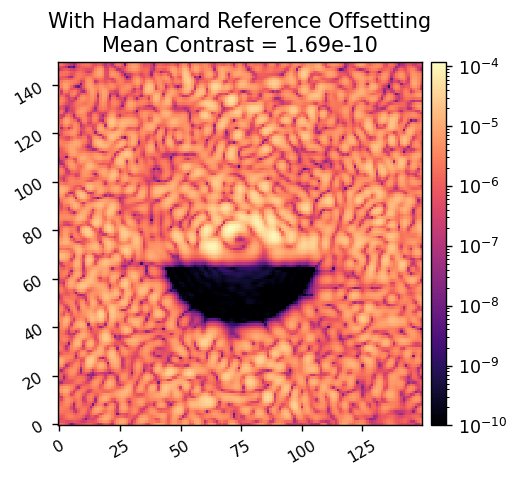

In [53]:
dark_hole_mask = llowfsc_data['dark_hole_mask']
mean_camsci_im = xp.mean(llowfsc_data['camsci_ims'][50:], axis=0)
mean_contrast = xp.mean( mean_camsci_im[dark_hole_mask])
print(mean_contrast)

imshow1(mean_camsci_im, f'With Hadamard Reference Offsetting\nMean Contrast = {mean_contrast:.2e}', lognorm=1, vmin=1e-10)

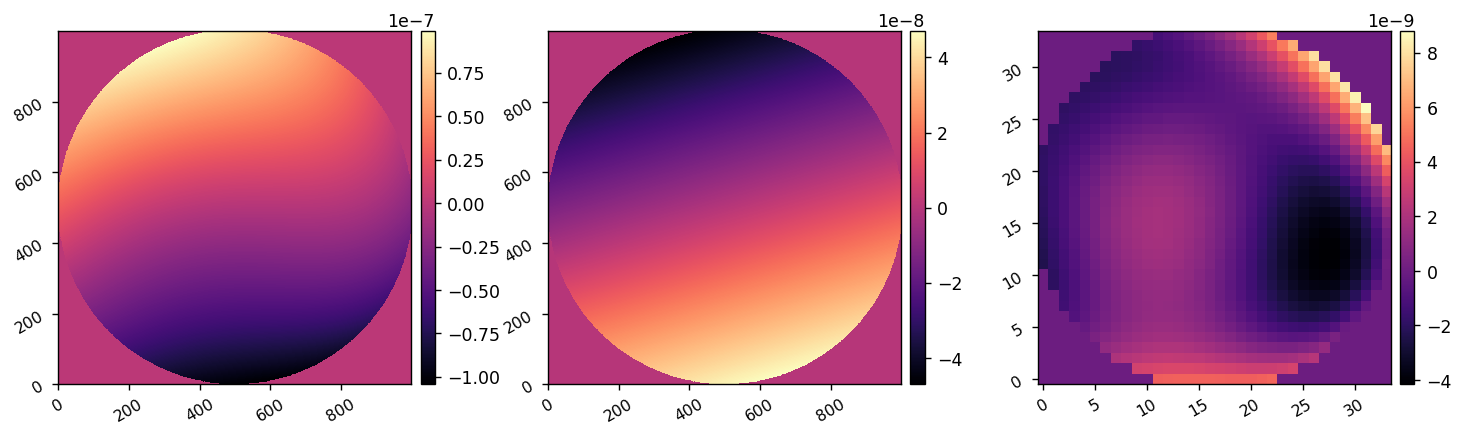

In [54]:
i = 10
wfe_coeff = llowfsc_data['injected_wfes'][i]
lo_wfe = xp.sum( wfe_coeff[:, None, None] * llowfsc_data['wfe_modes'], axis=0)
total_fsm_command = ensure_np_array(llowfsc_data['fsm_commands'][i])
fsm_modes = ensure_np_array(llowfsc_data['fsm_modes'])

fsm_rms = llowfsc.fsm_as_to_rms(total_fsm_command[1:], 7.1e-3)
total_fsm_rms = np.array([total_fsm_command[0], fsm_rms[0], fsm_rms[1]])
fsm_command = np.sum(total_fsm_rms[:, None, None] * fsm_modes, axis=0)
imshow3(lo_wfe, fsm_command, llowfsc_data['lo_dm_commands'][i])

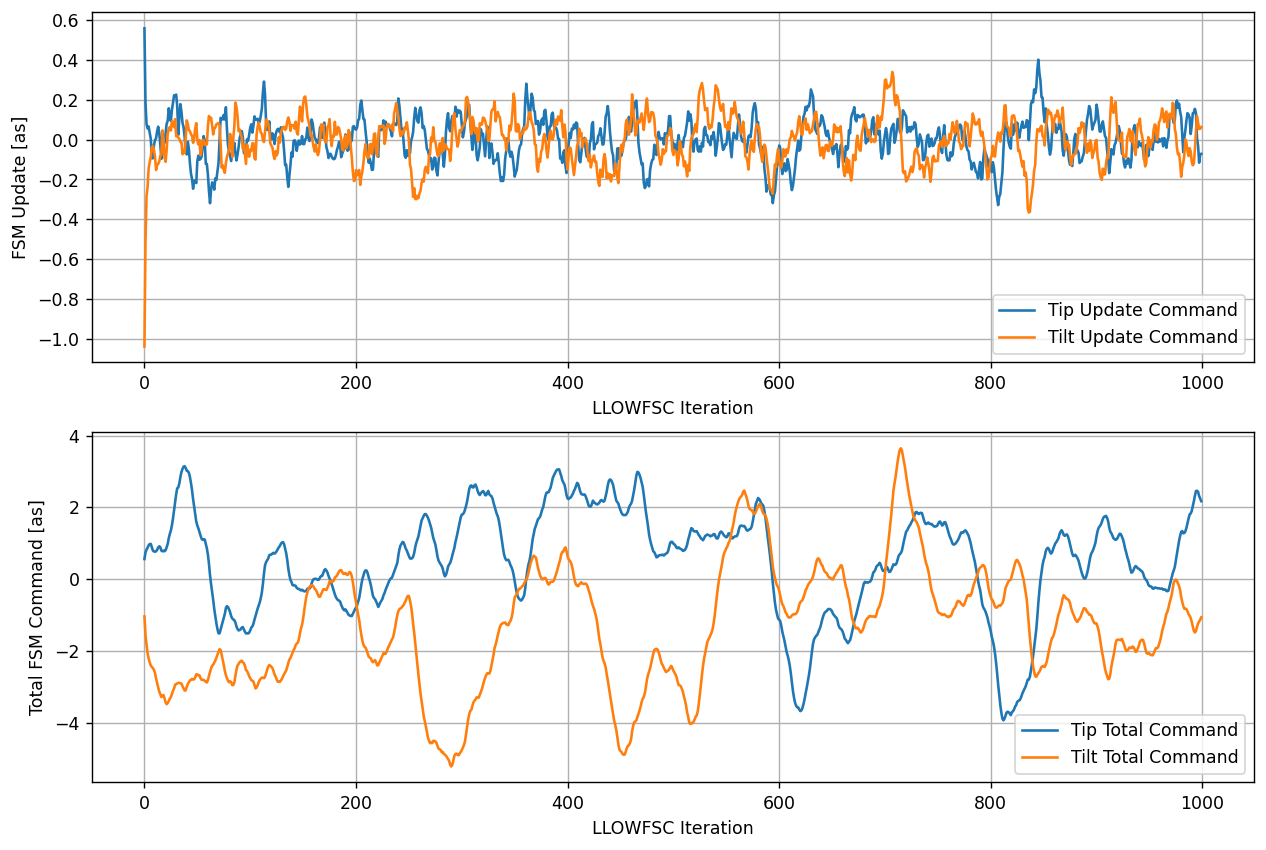

In [71]:
del_fsm_commands = ensure_np_array(llowfsc_data['del_fsm_commands'])
fsm_commands = ensure_np_array(llowfsc_data['fsm_commands'])

fig,axs = plt.subplots(nrows=2, ncols=1, figsize=(12,8), dpi=125)
ax = axs[0]
ax.plot(del_fsm_commands[:,1], label='Tip Update Command')
ax.plot(del_fsm_commands[:,2], label='Tilt Update Command')
ax.set_xlabel('LLOWFSC Iteration')
ax.set_ylabel('FSM Update [as]')
ax.legend(loc='lower right')
ax.grid()

ax = axs[1]
ax.plot(fsm_commands[:,1], label='Tip Total Command')
ax.plot(fsm_commands[:,2], label='Tilt Total Command')
ax.set_xlabel('LLOWFSC Iteration')
ax.set_ylabel('Total FSM Command [as]')
ax.legend(loc='lower right')
ax.grid()



In [72]:
def create_anim(
        data,
        numframes=None, 
        cmap1='magma', cmap2='magma', cmap3='magma', 
        cmap4='viridis', cmap5='viridis', cmap6='viridis',
        norm1=None, norm2=None, norm3=None, norm4=None, norm5=None, norm6=None, 
        extent1=None, extent2=None, extent3=None, extent4=None, extent5=None, extent6=None, 
        interval=0.005, # in seconds
        wspace=None,
        hspace=None,
    ):
    numframes = data['camsci_ims'].shape[0] if numframes is None else numframes
    print(numframes)
    i = 0
    time = i * interval

    wfe_modes = ensure_np_array(data['wfe_modes'])
    fsm_modes = ensure_np_array(llowfsc_data['fsm_modes'])
    wfe_series_coeff = ensure_np_array(data['injected_wfes'])
    llowfsc_mask = ensure_np_array(data['llowfsc_mask'])
    dark_hole_mask = ensure_np_array(data['dark_hole_mask'])

    camlo_im = ensure_np_array(data['camlo_ims'][i] )
    diff_im = ensure_np_array(data['diff_ims'][i] ) * llowfsc_mask
    camsci_im = ensure_np_array( data['camsci_ims'][i] ) 
    contrast = np.mean( camsci_im[dark_hole_mask] )
    wfe_coeff = wfe_series_coeff[i]
    lo_wfe = np.sum( wfe_coeff[:,None,None] * wfe_modes, axis=0 )
    total_fsm_command = ensure_np_array(llowfsc_data['fsm_commands'][i])
    fsm_rms = llowfsc.fsm_as_to_rms(total_fsm_command[1:], 7.1e-3)
    total_fsm_rms = np.array([total_fsm_command[0], fsm_rms[0], fsm_rms[1]])
    fsm_command = np.sum(total_fsm_rms[:, None, None] * fsm_modes, axis=0)
    lo_command = ensure_np_array( data['lo_dm_commands'][i] )

    fig,ax = plt.subplots(nrows=2, ncols=3, figsize=(15,9), dpi=125, gridspec_kw={'width_ratios': [1, 1, 1], })
    fig.suptitle(f'Time: {time:.3f}s\nLLOWFSC Iteration {i:d}', fontsize=16)

    im1 = ax[0,0].imshow(camlo_im, norm=norm1, cmap=cmap1, extent=extent1)
    im1_title = ax[0,0].set_title(f'CAMLO Image', fontsize=14)
    divider = make_axes_locatable(ax[0,0])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im1, cax=cax)

    im2 = ax[0,1].imshow( diff_im, norm=norm2, cmap=cmap2, extent=extent2)
    im2_title = ax[0,1].set_title(f'Difference Image', fontsize=14)
    divider = make_axes_locatable(ax[0,1])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im2, cax=cax,)

    im3 = ax[0,2].imshow(camsci_im, norm=norm3, cmap=cmap3, extent=extent3)
    im3_title = ax[0,2].set_title(f'CAMSCI Image: {contrast:.2e}', fontsize=14)
    divider = make_axes_locatable(ax[0,2])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im3, cax=cax)

    im4 = ax[1,0].imshow(lo_wfe, norm=norm4, cmap=cmap4, extent=extent4)
    im4_title = ax[1,0].set_title(f'Injected WFE', fontsize=14)
    divider = make_axes_locatable(ax[1,0])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im4, cax=cax)

    im5 = ax[1,1].imshow(fsm_command, norm=norm5, cmap=cmap5, extent=extent5)
    im5_title = ax[1,1].set_title(f'LLOWFSC FSM Command', fontsize=14)
    divider = make_axes_locatable(ax[1,1])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im5, cax=cax)

    im6 = ax[1,2].imshow(lo_command, norm=norm6, cmap=cmap6, extent=extent6)
    im6_title = ax[1,2].set_title(f'LLOWFSC DM Command', fontsize=14)
    divider = make_axes_locatable(ax[1,2])
    cax = divider.append_axes("right", size="4%", pad=0.075)
    cbar = fig.colorbar(im6, cax=cax,)

    ax[1,0].set_xticks([])
    ax[1,0].set_yticks([])
    ax[1,1].set_xticks([])
    ax[1,1].set_yticks([])

    plt.subplots_adjust(wspace=wspace, hspace=hspace)

    def animate(i):
        time = i * interval

        camlo_im = ensure_np_array(data['camlo_ims'][i] )
        diff_im = ensure_np_array(data['diff_ims'][i] ) * llowfsc_mask
        camsci_im = ensure_np_array( data['camsci_ims'][i] ) 
        contrast = np.mean( camsci_im[dark_hole_mask] )
        wfe_coeff = wfe_series_coeff[i]
        lo_wfe = np.sum( wfe_coeff[:,None,None] * wfe_modes, axis=0 )
        total_fsm_command = ensure_np_array(llowfsc_data['fsm_commands'][i])
        fsm_rms = llowfsc.fsm_as_to_rms(total_fsm_command[1:], 7.1e-3)
        total_fsm_rms = np.array([total_fsm_command[0], fsm_rms[0], fsm_rms[1]])
        fsm_command = np.sum(total_fsm_rms[:, None, None] * fsm_modes, axis=0)
        lo_command = ensure_np_array( data['lo_dm_commands'][i] )

        fig.suptitle(f'Time: {time:.3f}s\nLLOWFSC Iteration {i:d}', fontsize=16)
        im3_title.set_text(f'CAMSCI Image: {contrast:.2e}',)

        im1.set_data(camlo_im)
        im2.set_data(diff_im)
        im3.set_data(camsci_im)
        im4.set_data(lo_wfe)
        im5.set_data(fsm_command)
        im6.set_data(lo_command)

        im1.set_clim([0, np.max(camlo_im)])
        im2.set_clim([np.min(diff_im), np.max(diff_im)])
        im6.set_clim([np.min(lo_command), np.max(lo_command)])
        # im3.set_clim([np.min(del_command), np.max(del_command)])
        
    anim = matplotlib.animation.FuncAnimation(fig, animate, frames=numframes, interval=interval/1000) # wants interval in ms
    return anim

1000


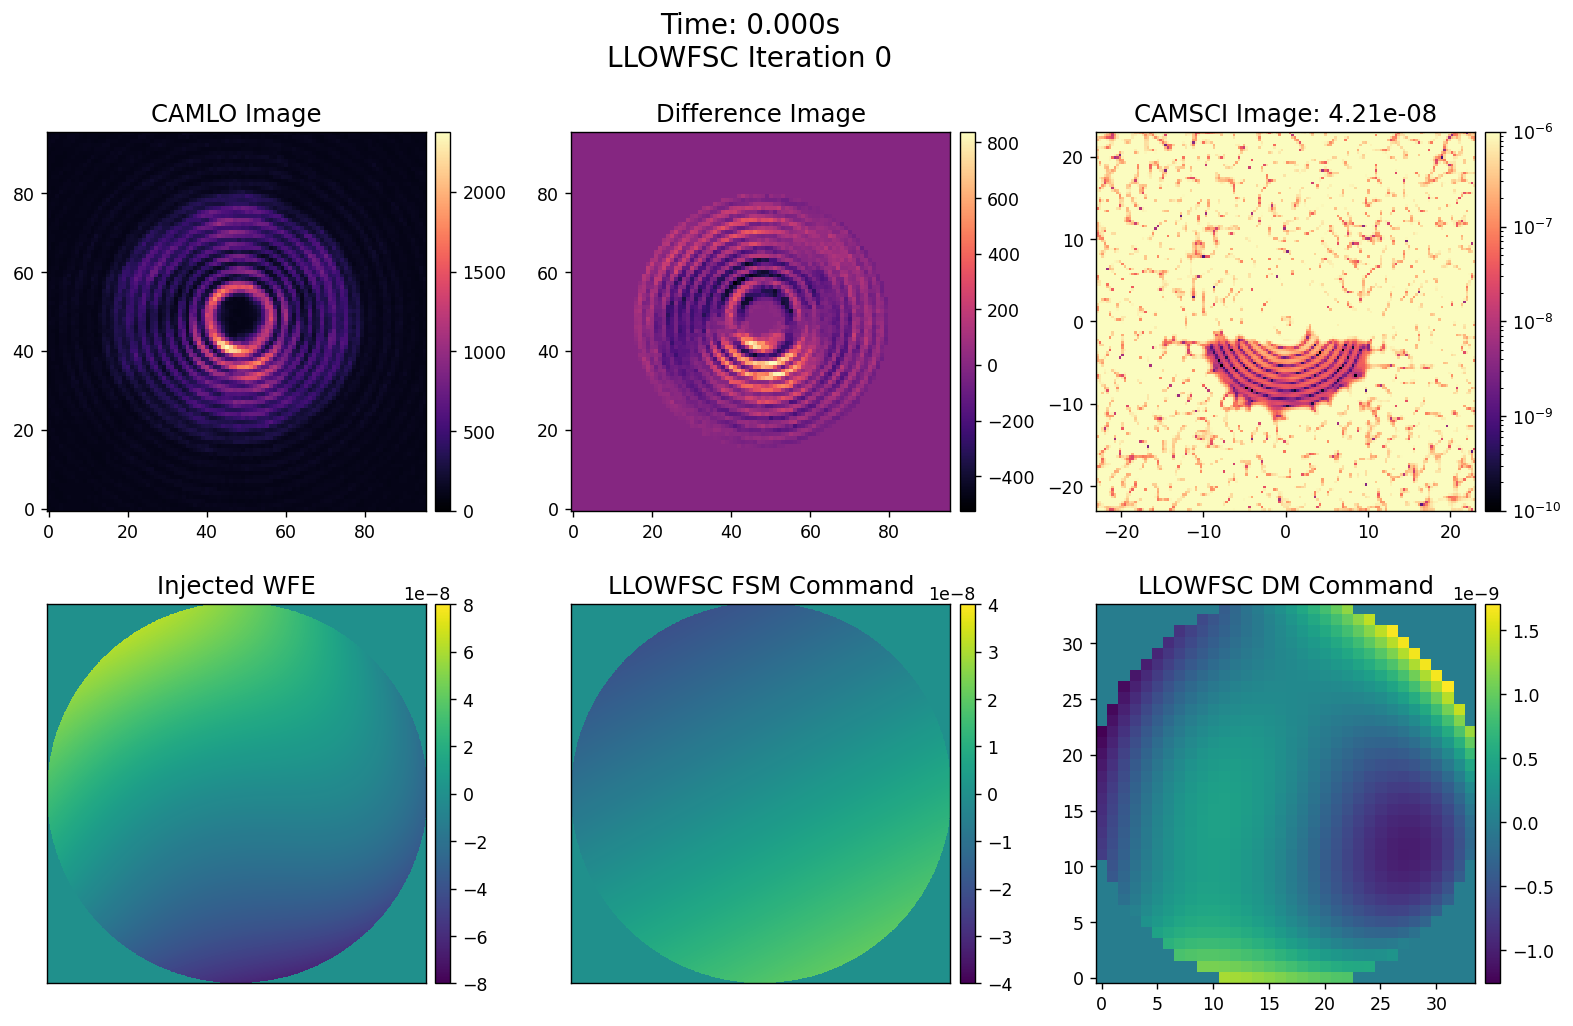

In [73]:
norm3 = LogNorm(vmin=1e-10, vmax=1e-6, clip=True)
norm4 = Normalize(vmin=-80e-9, vmax=80e-9, clip=True)
norm5 = Normalize(vmin=-40e-9, vmax=40e-9, clip=True)

camsci_pxscl = 0.307
ncamsci = llowfsc_data['camsci_ims'].shape[1]
camsci_lim = camsci_pxscl * ncamsci/2 
camsci_extent = [-camsci_lim, camsci_lim, -camsci_lim, camsci_lim]

interval = 0.01

anim = create_anim(
    llowfsc_data, 
    # numframes=100,
    # cmap4='viridis', cmap5='viridis', cmap6='viridis', 
    norm3=norm3,
    norm4=norm4,
    norm5=norm5,
    # norm6=norm6,
    extent3=camsci_extent,
    # interval=100,
    interval=interval, # in ms
    wspace=0.3,
)

In [76]:
1/0.0016 /60

10.416666666666666

In [74]:
writervideo = FFMpegWriter(fps=1/interval) 
anim.save(f'sim-data/llowfsc_sim_with_fsm_with_noise_100Hz.mp4', writer=writervideo)

In [17]:
anim